# Анализ временного ряда Favorita (train.csv)

В этом разделе:
- формируем данные без агрегирования train.csv: на уровне date + store_nbr + item_nbr;
- считаем отдельный статистический анализ для каждого ряда (store_nbr, item_nbr);
- строим пример временного ряда unit_sales для одной пары store_nbr/item_nbr;
- визуализируем ряд вплотную по всей истории;
- проверяем стационарность (rolling statistics, ADF, KPSS);
- выделяем тренд и сезонность через STL;
- проводим анализ остатков и тест Льюнга-Бокса.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [3]:
data_dir = Path('/content/drive/MyDrive/favorita-grocery-sales-forecasting (Unzipped Files)')
train_csv = data_dir / 'train.csv'

In [5]:
stores_df = pd.read_csv(train_csv, usecols=['store_nbr'])

stores_df['store_nbr'].unique()

array([25,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 23, 24, 26, 27, 28, 30, 31, 32, 33, 34, 35, 37, 38, 39,
       40, 41, 43, 44, 45, 46, 47, 48, 49, 50, 51, 54, 36, 53, 20, 29, 21,
       42, 22, 52])

In [6]:
np.random.seed(4207)
random_10_stores = np.random.choice(stores_df['store_nbr'].unique(), size=10)

random_10_stores

array([ 3, 28,  5, 35, 45, 53, 42, 54,  9, 18])

In [12]:
items_df = pd.read_csv(train_csv, usecols=['item_nbr'])

items_df['item_nbr'].unique()

array([ 103665,  105574,  105575, ..., 2126944, 2123839, 2011451])

In [13]:
np.random.seed(4207)
random_100_items = np.random.choice(items_df['item_nbr'].unique(), size=100)

random_100_items

array([ 457688,  876223,  949243, 1447815, 1958179, 1660193,  115847,
       1036689,  310644, 1463510,  805310, 1958231,  857331, 1658994,
        165553,  857331,  215468,  523054, 2016619,  953562, 1464094,
       1926106,  111397, 2026683, 1972443,  638977, 2018612,  977007,
        257847,  108862, 1696003, 1938600,  574898,  856687,  105857,
        849136,  413557, 1146797, 1237005,  371437, 1109389, 2046789,
       1459058, 1945572, 1017349, 1239862, 1005463, 1965358, 1489662,
       1695875, 1162382, 2010755, 1464070, 2011259, 2081050, 2011155,
        407608, 1464074, 1909453, 2053614, 2010793,  828630, 1239813,
        376194, 1105211, 1444615, 2010370, 1963684, 1726002,  116279,
       1393033, 2008747, 1473474, 1695875, 1457335, 1463857, 1456997,
       1176562, 1089820, 2047495,  796394,  205387, 1464210, 1167754,
       1428331,  559493, 2057762, 1940454,  795611,  956011, 1473483,
       1913257, 2058895,  261700,  165727,  977007, 1975602, 1464188,
       1370564, 1460

In [7]:
from tqdm import tqdm

In [14]:
# Читаем train.csv чанками без агрегирования, чтобы сохранить уровень (date, store_nbr, item_nbr).
chunksize = 20_000_000

parts = []
for chunk in tqdm(pd.read_csv(
    train_csv,
    usecols=['date', 'store_nbr', 'item_nbr', 'unit_sales'],
    parse_dates=['date'],
    chunksize=chunksize,
)):
    # В данных встречаются отрицательные значения возвратов; клипуем их в 0.
    chunk = chunk[(chunk['store_nbr'].isin(random_10_stores)) & (chunk['item_nbr'].isin(random_100_items))]
    chunk['unit_sales'] = chunk['unit_sales'].clip(lower=0)
    chunk = chunk.sort_values(['date'])
    parts.append(chunk)

if not parts:
    raise ValueError('Не удалось прочитать train.csv: файл пустой или не считан.')

train_panel = pd.concat(parts, ignore_index=True)
print('concated')
# train_panel = train_panel.sort_values(['store_nbr', 'item_nbr', 'date']).reset_index(drop=True)
# print("sorted")

print(train_panel.head())
print(train_panel.tail())
print(f'Строк в train_panel: {len(train_panel):,}')
print(f'Уникальных пар (store_nbr, item_nbr): {train_panel[["store_nbr", "item_nbr"]].drop_duplicates().shape[0]:,}')

# Для временного анализа ниже берём пару store/item с максимальной длиной истории.
pair_counts = train_panel.groupby(['store_nbr', 'item_nbr'], as_index=False).size()
target_pair = pair_counts.loc[pair_counts['size'].idxmax(), ['store_nbr', 'item_nbr']]
target_store = int(target_pair['store_nbr'])
target_item = int(target_pair['item_nbr'])

ts_daily = (
    train_panel[
        (train_panel['store_nbr'] == target_store)
        & (train_panel['item_nbr'] == target_item)
    ]
    .set_index('date')['unit_sales']
    .sort_index()
)
ts_daily.name = 'unit_sales'

print(f'Ряд для анализа: store_nbr={target_store}, item_nbr={target_item}, длина={len(ts_daily)}')
print(ts_daily.head())
print(ts_daily.tail())

0it [00:00, ?it/s]/tmp/ipykernel_40515/2249459972.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['unit_sales'] = chunk['unit_sales'].clip(lower=0)
1it [00:16, 16.81s/it]/tmp/ipykernel_40515/2249459972.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['unit_sales'] = chunk['unit_sales'].clip(lower=0)
2it [00:36, 18.68s/it]/tmp/ipykernel_40515/2249459972.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

concated
        date  store_nbr  item_nbr  unit_sales
0 2013-01-02          3    105857      36.000
1 2013-01-02         28    876223       7.000
2 2013-01-02         28    956011       4.000
3 2013-01-02         28   1017349       1.439
4 2013-01-02         28   1036689      13.000
             date  store_nbr  item_nbr  unit_sales
587861 2017-08-15          9   1464210        14.0
587862 2017-08-15          9   1464094        11.0
587863 2017-08-15          9   1464074        10.0
587864 2017-08-15          9   2010370         1.0
587865 2017-08-15         54   2053614         4.0
Строк в train_panel: 587,866
Уникальных пар (store_nbr, item_nbr): 830
Ряд для анализа: store_nbr=5, item_nbr=1036689, длина=1679
date
2013-01-02    38.0
2013-01-03    15.0
2013-01-04    10.0
2013-01-05    13.0
2013-01-06    20.0
Name: unit_sales, dtype: float64
date
2017-08-11    12.0
2017-08-12    15.0
2017-08-13    18.0
2017-08-14    17.0
2017-08-15    12.0
Name: unit_sales, dtype: float64


In [15]:
train_panel.shape

(587866, 4)

## Анализ каждого временного ряда отдельно

Ниже рассчитываются метрики по каждой паре `(store_nbr, item_nbr)`.

- `n_obs`, `date_min`, `date_max` — объём и покрытие истории;
- `mean_sales`, `std_sales`, `zero_share` — базовые статистики;
- `adf_pvalue`, `kpss_pvalue` и решения о стационарности — отдельная проверка для каждого ряда;
- `seasonality_strength`, `trend_strength` (опционально) — через STL, если включить `compute_stl_strength=True`.

Важно: для полного датасета расчёт по всем парам может занимать заметное время.

In [16]:
def analyze_pair_series(
    ts: pd.Series,
    min_len_for_tests: int = 30,
    compute_stl_strength: bool = False,
    stl_period: int = 7,
) -> dict:
    """Считает метрики одного временного ряда unit_sales."""
    ts = ts.dropna()

    result = {
        'n_obs': int(ts.shape[0]),
        'date_min': ts.index.min(),
        'date_max': ts.index.max(),
        'mean_sales': float(ts.mean()) if len(ts) else np.nan,
        'std_sales': float(ts.std(ddof=1)) if len(ts) > 1 else np.nan,
        'zero_share': float((ts == 0).mean()) if len(ts) else np.nan,
        'adf_pvalue': np.nan,
        'kpss_pvalue': np.nan,
        'adf_decision_5pct': 'not_tested',
        'kpss_decision_5pct': 'not_tested',
        'seasonality_strength': np.nan,
        'trend_strength': np.nan,
    }

    if len(ts) >= min_len_for_tests and ts.nunique() > 1:
        try:
            _, adf_pvalue, *_ = adfuller(ts, autolag='AIC')
            result['adf_pvalue'] = float(adf_pvalue)
            result['adf_decision_5pct'] = 'stationary' if adf_pvalue < 0.05 else 'non-stationary'
        except Exception:
            pass

        try:
            _, kpss_pvalue, *_ = kpss(ts, regression='c', nlags='auto')
            result['kpss_pvalue'] = float(kpss_pvalue)
            result['kpss_decision_5pct'] = 'stationary' if kpss_pvalue >= 0.05 else 'non-stationary'
        except Exception:
            pass

    if compute_stl_strength and len(ts) >= max(2 * stl_period, 14):
        try:
            stl_result_local = STL(ts, period=stl_period, robust=True).fit()
            resid_local = stl_result_local.resid
            seasonal_local = stl_result_local.seasonal
            trend_local = stl_result_local.trend

            result['seasonality_strength'] = float(
                1 - (np.var(resid_local) / np.var(resid_local + seasonal_local))
            )
            result['trend_strength'] = float(
                1 - (np.var(resid_local) / np.var(resid_local + trend_local))
            )
        except Exception:
            pass

    return result


min_len_for_tests = 30
compute_stl_strength = False  # Переключите в True, если нужен STL для каждой пары.

pair_reports = []
for (store_nbr, item_nbr), grp in train_panel.groupby(['store_nbr', 'item_nbr'], sort=False):
    ts_pair = (
        grp.sort_values('date')
        .set_index('date')['unit_sales']
        .groupby(level=0)
        .sum()
    )

    metrics = analyze_pair_series(
        ts_pair,
        min_len_for_tests=min_len_for_tests,
        compute_stl_strength=compute_stl_strength,
        stl_period=7,
    )
    metrics['store_nbr'] = int(store_nbr)
    metrics['item_nbr'] = int(item_nbr)
    pair_reports.append(metrics)

pair_analysis_df = pd.DataFrame(pair_reports)
pair_analysis_df = pair_analysis_df[
    [
        'store_nbr', 'item_nbr', 'n_obs', 'date_min', 'date_max',
        'mean_sales', 'std_sales', 'zero_share',
        'adf_pvalue', 'kpss_pvalue', 'adf_decision_5pct', 'kpss_decision_5pct',
        'seasonality_strength', 'trend_strength',
    ]
].sort_values(['n_obs', 'store_nbr', 'item_nbr'], ascending=[False, True, True]).reset_index(drop=True)

print(f'Всего проанализировано рядов: {len(pair_analysis_df):,}')
display(pair_analysis_df.head(20))
pair_analysis_df.describe(include='all').T

/tmp/ipykernel_40515/1117652368.py:34: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  _, kpss_pvalue, *_ = kpss(ts, regression='c', nlags='auto')
/tmp/ipykernel_40515/1117652368.py:34: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  _, kpss_pvalue, *_ = kpss(ts, regression='c', nlags='auto')
/tmp/ipykernel_40515/1117652368.py:34: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  _, kpss_pvalue, *_ = kpss(ts, regression='c', nlags='auto')
/tmp/ipykernel_40515/1117652368.py:34: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value r

Всего проанализировано рядов: 830


,store_nbr,item_nbr,n_obs,date_min,date_max,mean_sales,std_sales,zero_share,adf_pvalue,kpss_pvalue,adf_decision_5pct,kpss_decision_5pct,seasonality_strength,trend_strength
0,5,1036689,1679,2013-01-02,2017-08-15,18.843359,9.841285,0.000000,3.246454e-06,0.010000,stationary,non-stationary,NaN,NaN
1,3,205387,1676,2013-01-03,2017-08-15,12.760143,6.876461,0.000000,4.178211e-04,0.010000,stationary,non-stationary,NaN,NaN
2,3,1036689,1676,2013-01-02,2017-08-15,59.006563,30.727312,0.000000,2.983972e-08,0.010000,stationary,non-stationary,NaN,NaN
3,9,1017349,1676,2013-01-02,2017-08-15,24.243680,11.226766,0.000000,1.132395e-05,0.010000,stationary,non-stationary,NaN,NaN
4,45,205387,1676,2013-01-02,2017-08-15,23.701671,11.911385,0.000000,9.307364e-10,0.034692,stationary,non-stationary,NaN,NaN
5,45,261700,1676,2013-01-02,2017-08-15,9.313842,4.969814,0.000000,1.773642e-05,0.010000,stationary,non-stationary,NaN,NaN
6,45,1036689,1676,2013-01-02,2017-08-15,73.581742,40.110309,0.000000,6.223083e-12,0.017539,stationary,non-stationary,NaN,NaN
7,9,559493,1673,2013-01-02,2017-08-15,23.524806,11.075729,0.000000,1.472821e-09,0.020938,stationary,non-stationary,NaN,NaN
8,9,261700,1672,2013-01-02,2017-08-15,12.362440,6.555310,0.000000,5.297855e-09,0.010000,stationary,non-stationary,NaN,NaN
9,9,1036689,1672,2013-01-02,2017-08-15,22.815191,13.004301,0.000000,7.619855e-07,0.033382,stationary,non-stationary,NaN,NaN


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
store_nbr,830.0,NaN,NaN,NaN,28.657831,3.0,9.0,28.0,45.0,54.0,18.563581
item_nbr,830.0,NaN,NaN,NaN,1244230.703614,105857.0,828630.0,1393033.0,1913257.0,2081050.0,626121.497378
n_obs,830.0,NaN,NaN,NaN,708.272289,1.0,239.5,662.0,1027.0,1679.0,506.198322
date_min,830,NaN,NaN,NaN,2014-08-09 18:52:54.939758848,2013-01-02 00:00:00,2013-01-10 06:00:00,2014-05-10 00:00:00,2015-10-01 00:00:00,2017-07-04 00:00:00,NaN
date_max,830,NaN,NaN,NaN,2017-07-14 23:32:14.457831424,2013-08-24 00:00:00,2017-08-11 00:00:00,2017-08-15 00:00:00,2017-08-15 00:00:00,2017-08-15 00:00:00,NaN
mean_sales,830.0,NaN,NaN,NaN,9.909114,0.535,2.378427,3.965236,8.620729,379.622817,23.759587
std_sales,828.0,NaN,NaN,NaN,8.793954,0.226294,1.837755,3.369993,6.745828,325.624693,24.011701
zero_share,830.0,NaN,NaN,NaN,0.000088,0.0,0.0,0.0,0.0,0.0181,0.000837
adf_pvalue,809.0,NaN,NaN,NaN,0.014937,0.0,0.0,0.0,0.000465,0.99491,0.067243
kpss_pvalue,809.0,NaN,NaN,NaN,0.054512,0.01,0.01,0.048247,0.1,0.1,0.041442


In [17]:
# Быстрый срез: сколько рядов стационарны по ADF/KPSS
stationarity_summary = pd.DataFrame({
    'ADF_stationary_share': [
        (pair_analysis_df['adf_decision_5pct'] == 'stationary').mean()
    ],
    'KPSS_stationary_share': [
        (pair_analysis_df['kpss_decision_5pct'] == 'stationary').mean()
    ],
    'tested_rows_share': [
        (pair_analysis_df['adf_decision_5pct'] != 'not_tested').mean()
    ],
})

stationarity_summary

,ADF_stationary_share,KPSS_stationary_share,tested_rows_share
0,0.90241,0.485542,0.974699


In [29]:
train_panel.head()

,date,store_nbr,item_nbr,unit_sales
0,2013-01-02,3,105857,36.000
1,2013-01-02,28,876223,7.000
2,2013-01-02,28,956011,4.000
3,2013-01-02,28,1017349,1.439
4,2013-01-02,28,1036689,13.000


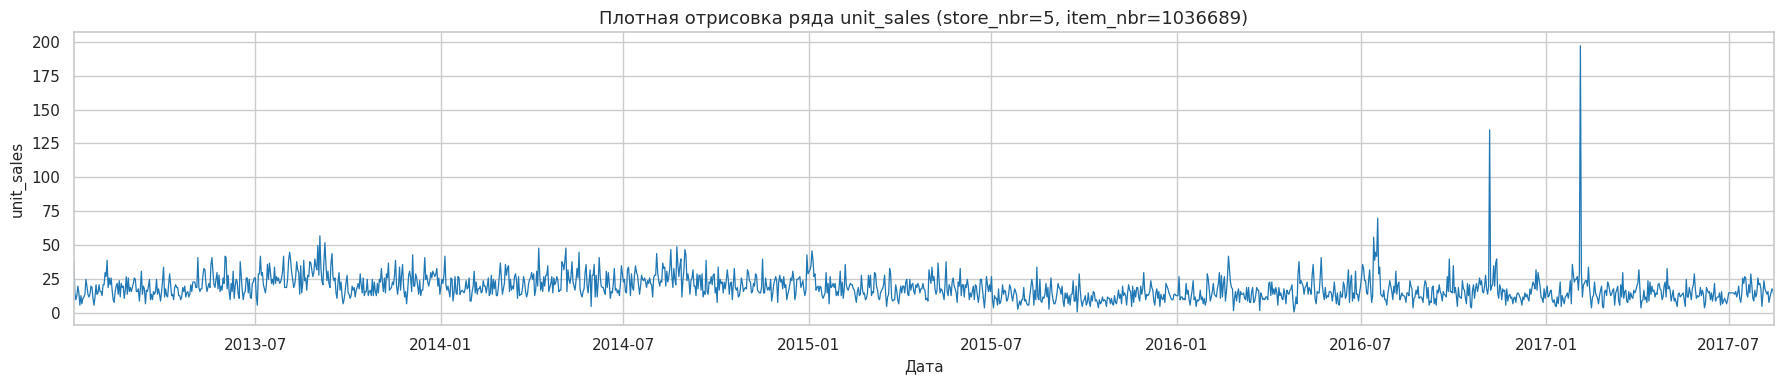

In [18]:
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(ts_daily.index, ts_daily.values, color='tab:blue', linewidth=0.9)
ax.set_title(f'Плотная отрисовка ряда unit_sales (store_nbr={target_store}, item_nbr={target_item})')
ax.set_xlabel('Дата')
ax.set_ylabel('unit_sales')
ax.margins(x=0)
plt.tight_layout()
plt.show()

In [19]:
import plotly.io as pio
pio.renderers.default = "vscode"

In [20]:
import os
import sys

import plotly.express as px

fig = px.line(
    x=ts_daily.index,
    y=ts_daily.values,
    labels={"x": "Дата", "y": "unit_sales"},
    title=f"Интерактивный ряд unit_sales (store_nbr={target_store}, item_nbr={target_item})",
)
fig.update_traces(line=dict(color="royalblue", width=1))
fig.update_layout(height=420, hovermode="x unified")
fig.show()

Сезонность в 7 дней

Частота в день

In [21]:
def stationarity_report(series: pd.Series, title: str) -> pd.DataFrame:
    series = series.dropna()

    adf_stat, adf_pvalue, *_ = adfuller(series, autolag='AIC')
    kpss_stat, kpss_pvalue, *_ = kpss(series, regression='c', nlags='auto')

    report = pd.DataFrame(
        {
            'test': ['ADF', 'KPSS'],
            'statistic': [adf_stat, kpss_stat],
            'p_value': [adf_pvalue, kpss_pvalue],
            'decision_5pct': [
                'stationary' if adf_pvalue < 0.05 else 'non-stationary',
                'stationary' if kpss_pvalue >= 0.05 else 'non-stationary',
            ],
        }
    )
    print(f'=== {title} ===')
    display(report)
    return report

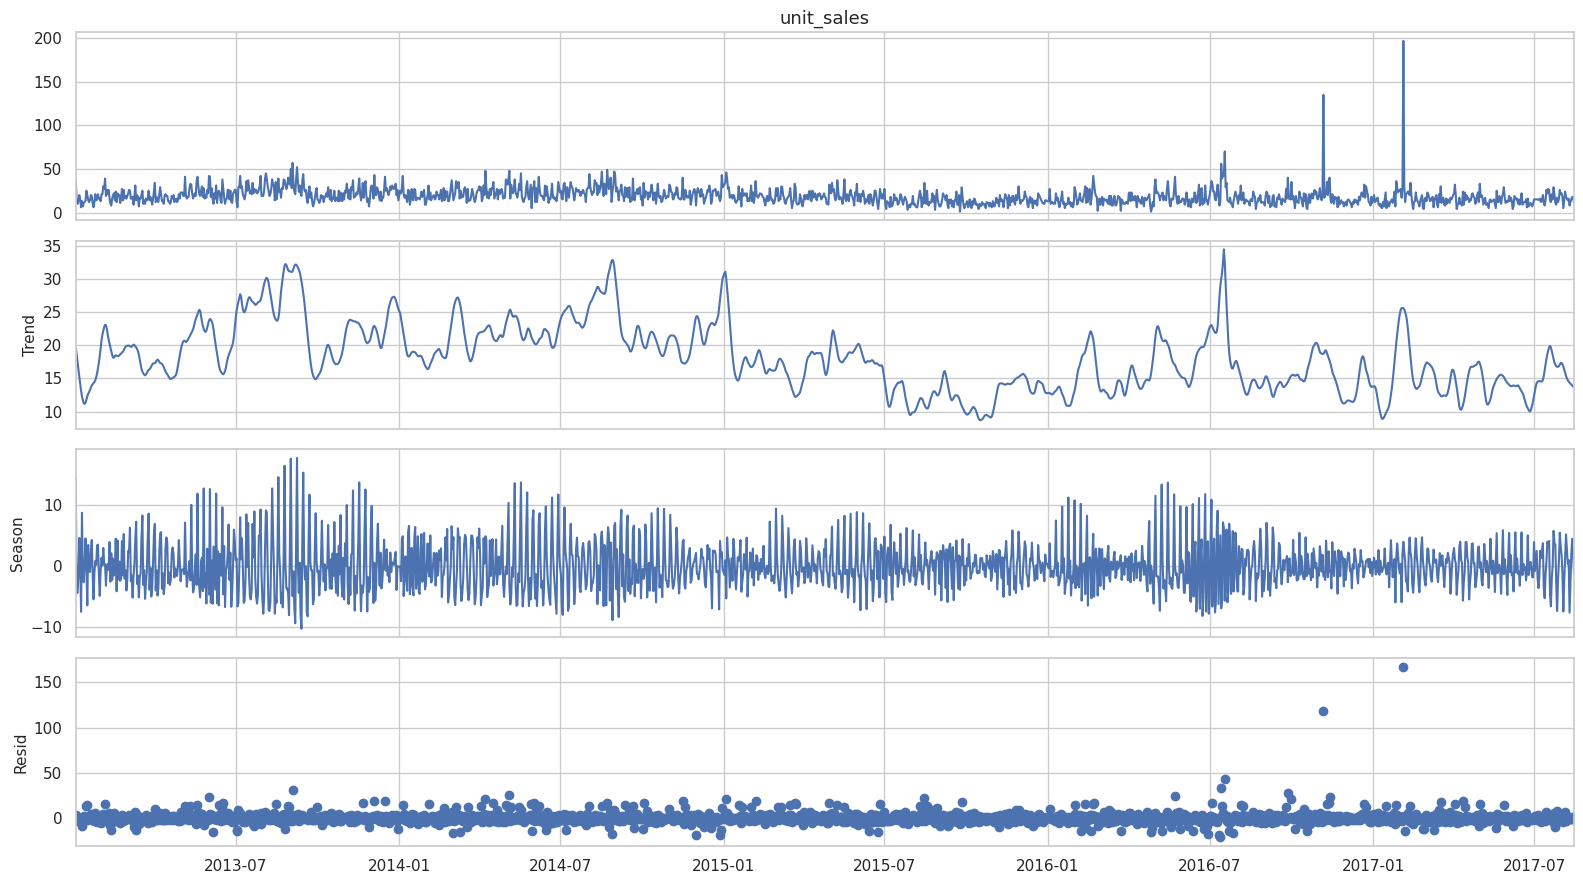

In [23]:
# Декомпозиция ряда на тренд, сезонность и остатки.
# Для дневных данных в ритейле обычно значима недельная сезонность, поэтому period=7.
stl = STL(ts_daily, period=7, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(16, 9)
plt.tight_layout()
plt.show()

trend = stl_result.trend
seasonal = stl_result.seasonal
resid = stl_result.resid

In [24]:
seasonality_strength = 1 - (np.var(resid) / np.var(resid + seasonal))
trend_strength = 1 - (np.var(resid) / np.var(resid + trend))

print(f'Strength of seasonality: {seasonality_strength:.4f}')
print(f'Strength of trend: {trend_strength:.4f}')

if seasonality_strength > 0.3:
    print('Сезонность выражена.')
else:
    print('Явно выраженной сезонности не обнаружено.')

Strength of seasonality: 0.2089
Strength of trend: 0.3497
Явно выраженной сезонности не обнаружено.


In [25]:
# Стационарность
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [26]:
def check_stationary(ts):
    
    _, p_value, _, _ = kpss(ts)
    print(f"KPSS p-value: {p_value}")
    _, p_value, _, _, _, _ = adfuller(ts)
    print(f"AD Fuller p-value: {p_value}")

    # ACF и PACF
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(ts, lags=40, ax=ax[0])
    plot_pacf(ts, lags=40, ax=ax[1])
    plt.show()


/tmp/ipykernel_40515/1118135061.py:3: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




KPSS p-value: 0.01
AD Fuller p-value: 3.246453669914623e-06


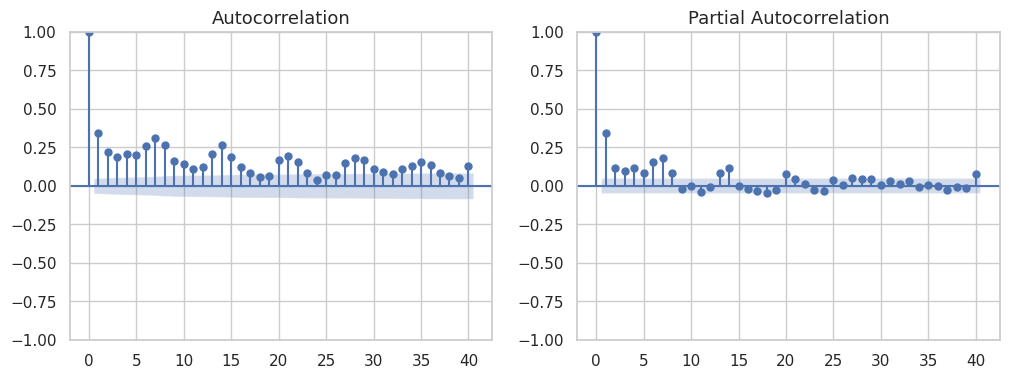

In [27]:
check_stationary(ts_daily)

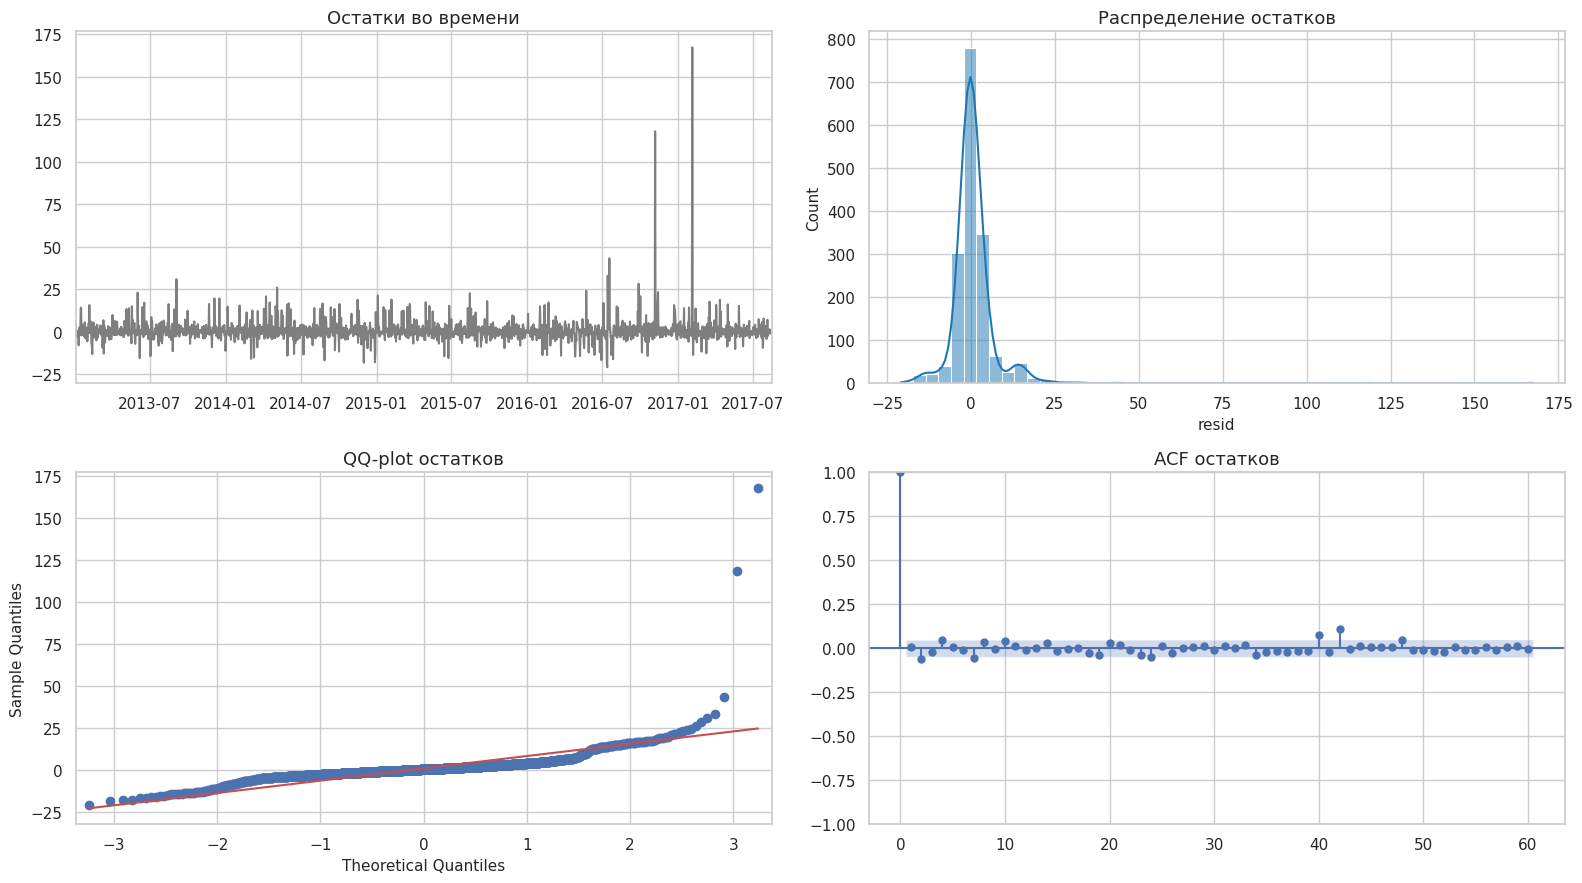

,lb_stat,lb_pvalue
7,15.891035,0.026131
14,23.352520,0.054770
30,38.309463,0.141965


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

axes[0, 0].plot(resid.index, resid.values, color='tab:gray')
axes[0, 0].set_title('Остатки во времени')
axes[0, 0].margins(x=0)

sns.histplot(resid.dropna(), bins=50, kde=True, ax=axes[0, 1], color='tab:blue')
axes[0, 1].set_title('Распределение остатков')

sm.qqplot(resid.dropna(), line='s', ax=axes[1, 0])
axes[1, 0].set_title('QQ-plot остатков')

plot_acf(resid.dropna(), lags=60, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid.dropna(), lags=[7, 14, 30], return_df=True)
lb